In [3]:
import torch
print(torch.cuda.is_available())        # debe decir True
print(torch.cuda.get_device_name(0))    # debe decir algo como "Tesla T4"

True
Tesla T4


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

print("Todo importado correctamente")

Todo importado correctamente


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
# Ruta corregida para esta cuenta
data_dir = '/content/drive/MyDrive/landmark_images'

train_dir = os.path.join(data_dir, 'train')
test_dir  = os.path.join(data_dir, 'test')

# Verificar
clases = os.listdir(train_dir)
print(f"Clases encontradas: {len(clases)}")
print(f"Primeras 5 clases: {clases[:5]}")

Clases encontradas: 50
Primeras 5 clases: ['46.Great_Wall_of_China', '45.Temple_of_Heaven', '44.Trevi_Fountain', '48.Whitby_Abbey', '47.Prague_Astronomical_Clock']


In [7]:
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transformaciones listas")

Transformaciones listas


In [8]:
full_train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)

train_size = int(0.8 * len(full_train_dataset))
val_size   = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

val_dataset.dataset = datasets.ImageFolder(train_dir, transform=val_test_transforms)

test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transforms)

num_classes  = len(full_train_dataset.classes)
class_names  = full_train_dataset.classes

print(f"Total train:      {len(train_dataset)} imágenes")
print(f"Total validación: {len(val_dataset)} imágenes")
print(f"Total test:       {len(test_dataset)} imágenes")
print(f"Número de clases: {num_classes}")

Total train:      3996 imágenes
Total validación: 1000 imágenes
Total test:       1250 imágenes
Número de clases: 50


In [9]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Batches en train:      {len(train_loader)}")
print(f"Batches en validación: {len(val_loader)}")
print(f"Batches en test:       {len(test_loader)}")

Batches en train:      63
Batches en validación: 16
Batches en test:       20


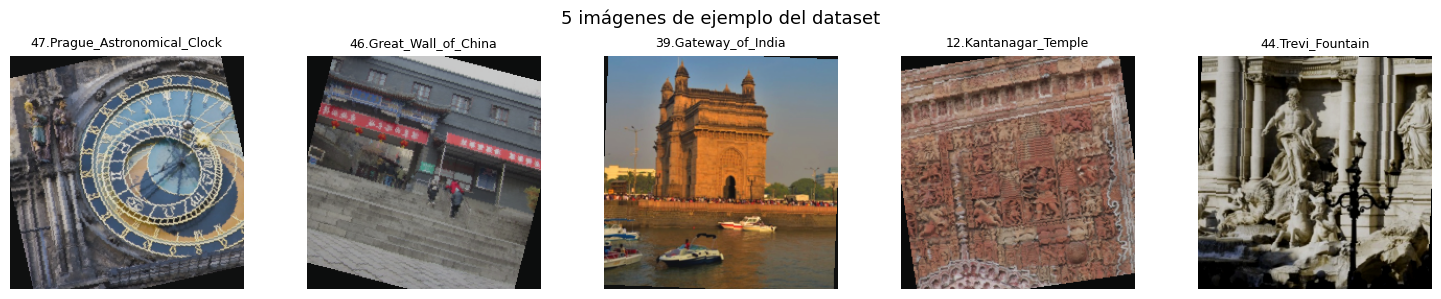

In [10]:
def imshow(img, title):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = std * img + mean
    img  = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title, fontsize=9)
    plt.axis('off')

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    plt.sca(axes[i])
    imshow(images[i], class_names[labels[i]])

plt.suptitle("5 imágenes de ejemplo del dataset", fontsize=13)
plt.tight_layout()
plt.show()

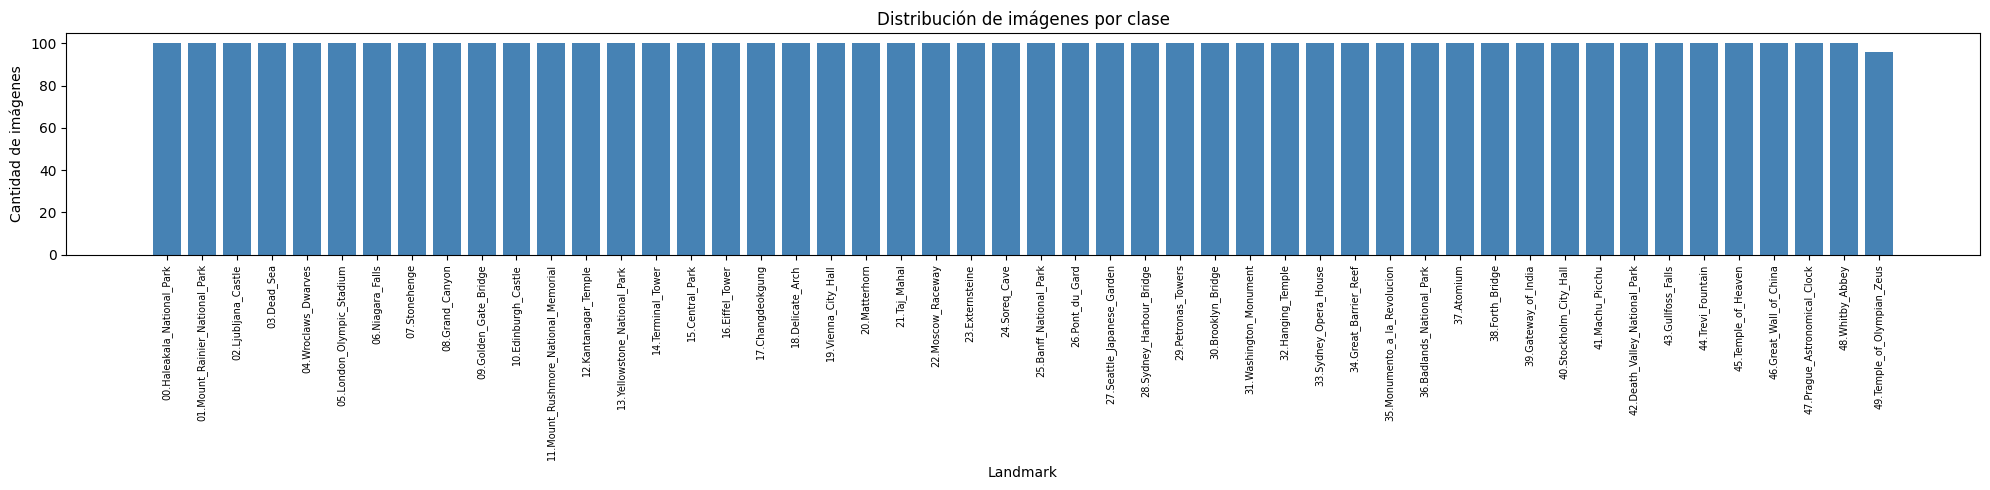

Clase con más imágenes:   00.Haleakala_National_Park  (100 imgs)
Clase con menos imágenes: 49.Temple_of_Olympian_Zeus (96 imgs)


In [11]:
class_counts = {}
for _, label in full_train_dataset.imgs:
    class_name = class_names[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
nombres, cantidades = zip(*sorted_classes)

plt.figure(figsize=(20, 5))
plt.bar(range(len(nombres)), cantidades, color='steelblue')
plt.xticks(range(len(nombres)), nombres, rotation=90, fontsize=7)
plt.xlabel("Landmark")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase")
plt.tight_layout()
plt.show()

print(f"Clase con más imágenes:   {sorted_classes[0][0]}  ({sorted_classes[0][1]} imgs)")
print(f"Clase con menos imágenes: {sorted_classes[-1][0]} ({sorted_classes[-1][1]} imgs)")

In [12]:
class CNNFromScratch(nn.Module):
    def __init__(self, num_classes=50):
        super(CNNFromScratch, self).__init__()

        ## Encoder: 3 bloques Conv + ReLU + MaxPool ##
        self.features = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 224x224x3 -> 224x224x32
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # -> 112x112x32

            # Bloque 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # -> 112x112x64
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # -> 56x56x64

            # Bloque 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# -> 56x56x128
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                            # -> 28x28x128
        )

        ## Clasificador final ##
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Crear el modelo y moverlo a GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = CNNFromScratch(num_classes=50).to(device)

print(f"Modelo creado en: {device}")
print(model)

Modelo creado en: cuda
CNNFromScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=50, bias=True)
  )
)


In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss y optimizer listos")

Loss y optimizer listos


In [14]:
n_epochs = 30

train_losses = []
val_losses   = []
train_accs   = []
val_accs     = []

best_val_loss = float('inf')  # infinito, cualquier loss va a ser menor

for epoch in range(1, n_epochs + 1):

    # ---- ENTRENAMIENTO ----
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    train_loss = running_loss / total
    train_acc  = correct / total

    # ---- VALIDACIÓN ----
    model.eval()
    val_running_loss = 0.0
    val_correct      = 0
    val_total        = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)
            _, predicted      = outputs.max(1)
            val_correct      += predicted.eq(labels).sum().item()
            val_total        += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc  = val_correct / val_total

    # Guardar métricas
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Guardar mejor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_scratch.pth')
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} ⭐ modelo guardado")
    else:
        print(f"Epoch {epoch:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

Epoch 01 | Train Loss: 3.9628 | Val Loss: 3.7462 | Train Acc: 0.0320 | Val Acc: 0.0790 ⭐ modelo guardado
Epoch 02 | Train Loss: 3.7550 | Val Loss: 3.5982 | Train Acc: 0.0653 | Val Acc: 0.1080 ⭐ modelo guardado
Epoch 03 | Train Loss: 3.6541 | Val Loss: 3.4817 | Train Acc: 0.0828 | Val Acc: 0.1240 ⭐ modelo guardado
Epoch 04 | Train Loss: 3.5835 | Val Loss: 3.4629 | Train Acc: 0.0963 | Val Acc: 0.1280 ⭐ modelo guardado
Epoch 05 | Train Loss: 3.4874 | Val Loss: 3.3282 | Train Acc: 0.1156 | Val Acc: 0.1650 ⭐ modelo guardado
Epoch 06 | Train Loss: 3.3952 | Val Loss: 3.2069 | Train Acc: 0.1406 | Val Acc: 0.1820 ⭐ modelo guardado
Epoch 07 | Train Loss: 3.3189 | Val Loss: 3.1368 | Train Acc: 0.1569 | Val Acc: 0.2140 ⭐ modelo guardado
Epoch 08 | Train Loss: 3.2212 | Val Loss: 3.0767 | Train Acc: 0.1797 | Val Acc: 0.2150 ⭐ modelo guardado
Epoch 09 | Train Loss: 3.1142 | Val Loss: 2.9751 | Train Acc: 0.2060 | Val Acc: 0.2390 ⭐ modelo guardado
Epoch 10 | Train Loss: 3.0292 | Val Loss: 2.8496 | Trai

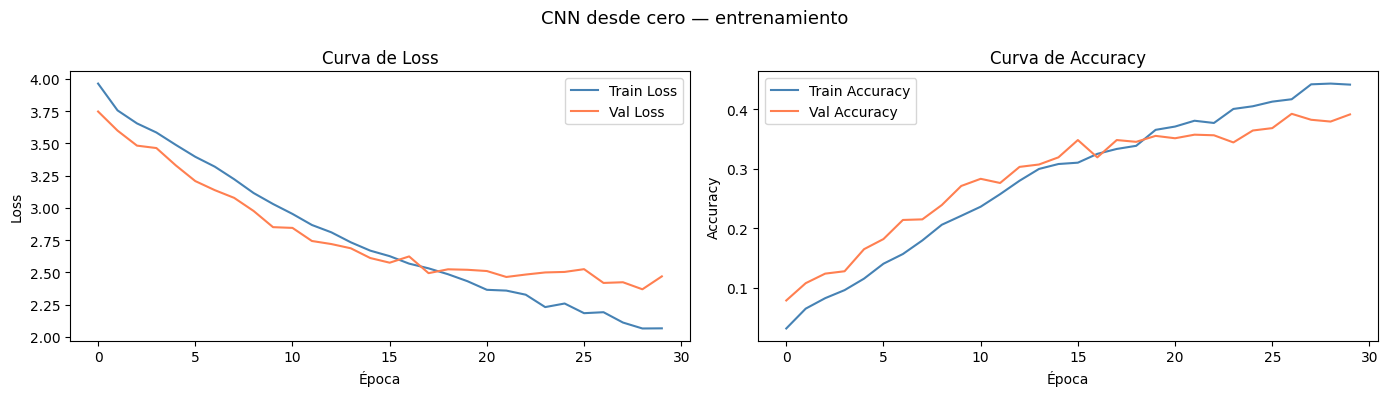

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfica de Loss
axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='coral')
axes[0].set_title('Curva de Loss')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Gráfica de Accuracy
axes[1].plot(train_accs, label='Train Accuracy', color='steelblue')
axes[1].plot(val_accs,   label='Val Accuracy',   color='coral')
axes[1].set_title('Curva de Accuracy')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('CNN desde cero — entrenamiento', fontsize=13)
plt.tight_layout()
plt.show()

In [16]:
# Cargar el mejor modelo guardado
model.load_state_dict(torch.load('best_model_scratch.pth'))
model.eval()

test_correct = 0
test_total   = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = outputs.max(1)
        test_correct  += predicted.eq(labels).sum().item()
        test_total    += labels.size(0)

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# Exportar con Torch Script
scripted_model = torch.jit.script(model.cpu())
scripted_model.save('model_scratch_scripted.pt')
print("Modelo exportado con Torch Script")

Test Accuracy: 0.4312 (43.12%)
Modelo exportado con Torch Script
